# VNExpress News Data Overview
VNEXpress là một trong những trang báo điện tử lớn nhất tại Việt Nam, cung cấp tin tức về nhiều lĩnh vực như chính trị, kinh tế, xã hội, thể thao, giải trí và công nghệ. Dưới đây là một số thông tin về dữ liệu từ VNExpress:
* 1. Nguồn dữ liệu: VNExpress
* 2. Thời gian thu thập: Từ tháng 1 năm 2026 đến tháng 3 năm 2026
* 3. Các lĩnh vực tin tức: Công nghệ, Khoa học, Sức khoẻ, Thể thao, Giải trí, Chính trị, Kinh tế, Xã hội,...
* 4. Số lượng bài viết: Khoảng 100.000 bài viết

Notebook này thực hiện khảo sát và thống kê sơ bộ dữ liệu thu thập từ VNExpress, tập trung vào hai nhóm bài viết: 
* "Sức khoẻ" và "Giải trí".

## Dữ liệu bao gồm các trường
* `title`: Tiêu đề bài viết
* `description`: Mô tả ngắn gọn 
* `date`: Ngày giờ xuất bản bài viết
* `category`: Thể loại bài viết (Ví dụ: Phim, Nhạc, Hô hấp, Thần kinh,...)
* `thumbnail`: Đường dẫn đến hình ảnh đại diện bài viết
* `content`: Nội dung bài viết
* `author`: Tác giả bài viết
* `tags`: Các thẻ liên quan đến bài viết
* `group`: Danh mục bài viết (Sức khoẻ, Giải trí)
* `nums_of_comments`: Số lượng bình luận bài viết
* `url`: Đường dẫn đến bài viết




## 1. Import các thư viện cần thiết

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [25]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv", encoding="utf-8")

print("Kích thước dataset:", df.shape)

Kích thước dataset: (1181, 11)


### 2.2 Xem vài dòng dữ liệu đầu

In [26]:
df.head()

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,Các yếu tố âm thầm gây hại phổi ngoài thuốc lá,"Không chỉ thuốc lá, môi trường làm việc thường...","Thứ sáu, 27/2/2026, 18:00 (GMT+7)",Hút thuốc lá không phải là thủ phạm duy nhất g...,https://i1-suckhoe.vnecdn.net/2026/02/27/1428b...,Lê Nguyễn,"hô hấp, tổn thương phổi",Sức khỏe,Các bệnh,0,https://vnexpress.net/cac-yeu-to-am-tham-gay-h...
1,Đội trưởng Tạ phim 'Mưa đỏ' đóng MV của Đàm Vĩ...,"Phương Nam - đội trưởng Tạ phim ""Mưa đỏ"" - cùn...","Chủ nhật, 8/2/2026, 10:10 (GMT+7)","Phương Nam, Lâm Thanh Nhã hóa thân thành những...",https://i1-giaitri.vnecdn.net/2026/02/02/phuon...,Hoàng Dung,"đàm vĩnh hưng, phương nam, lâm thanh nhã, mưa đỏ",Giải trí,Nhạc,0,https://vnexpress.net/doi-truong-ta-phim-mua-d...
2,Phẫu thuật Whipple là gì?,"Tôi có khối u ở đầu tuyến tụy, bác sĩ tư vấn p...","Thứ ba, 3/3/2026, 12:00 (GMT+7)",Trả lời:\nPhẫu thuật Whipple là kỹ thuật cắt b...,https://i1-suckhoe.vnecdn.net/2026/03/03/pic-1...,ThS.BS Đào Văn Minh,"u tá tụy, mổ nội soi",Sức khỏe,Các bệnh,0,https://vnexpress.net/phau-thuat-whipple-la-gi...
3,Nhà văn Nguyễn Ngọc Tiến: 'Tết Nguyên đán giá ...,Ông Nguyễn Ngọc Tiến - tác giả nhiều khảo cứu ...,"Thứ tư, 18/2/2026, 05:00 (GMT+7)",Nhà văn Nguyễn Ngọc Tiến sinh ra và lớn lên ở ...,https://i1-giaitri.vnecdn.net/2026/02/17/nguye...,Phương Linh,"nhà văn nguyễn ngọc tiến, tết hà nội",Giải trí,Sách,0,https://vnexpress.net/nha-van-nguyen-ngoc-tien...
4,Bé 3 ngày tuổi được phẫu thuật cắt u vùng cùng...,"TP HCMBé gái chào đời nặng 3,7 kg với khối u g...","Thứ sáu, 27/2/2026, 13:00 (GMT+7)","Ngay từ trong bụng mẹ, bé được siêu âm tháng t...",https://i1-suckhoe.vnecdn.net/2026/02/27/image...,Giản Đơn,"tp hcm, khối u, trẻ sơ sinh, phẫu thuật khối u",Sức khỏe,Các bệnh,0,https://vnexpress.net/be-3-ngay-tuoi-duoc-phau...


### 2.3 Thông tin các cột dữ liệu

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1181 non-null   str  
 1   description       1181 non-null   str  
 2   date              1181 non-null   str  
 3   content           1181 non-null   str  
 4   thumbnail         1181 non-null   str  
 5   author            1181 non-null   str  
 6   tags              1176 non-null   str  
 7   group             1181 non-null   str  
 8   category          1181 non-null   str  
 9   nums_of_comments  1181 non-null   int64
 10  url               1181 non-null   str  
dtypes: int64(1), str(10)
memory usage: 101.6 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [28]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
tags,5,0.42337
title,0,0.00000
description,0,0.00000
date,0,0.00000
content,0,0.00000
thumbnail,0,0.00000
author,0,0.00000
group,0,0.00000
category,0,0.00000
nums_of_comments,0,0.00000


### 2.5 Thống kê mô tả

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nums_of_comments,1181.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

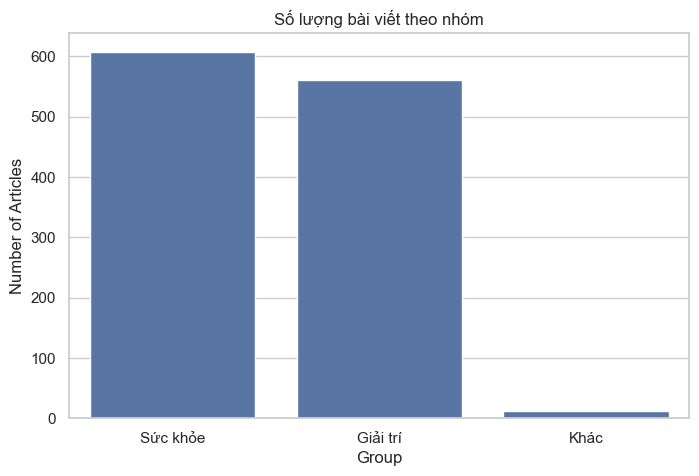

In [30]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel("Group")
plt.ylabel("Number of Articles")

plt.show()

### 3.2 Số lượng bài theo category

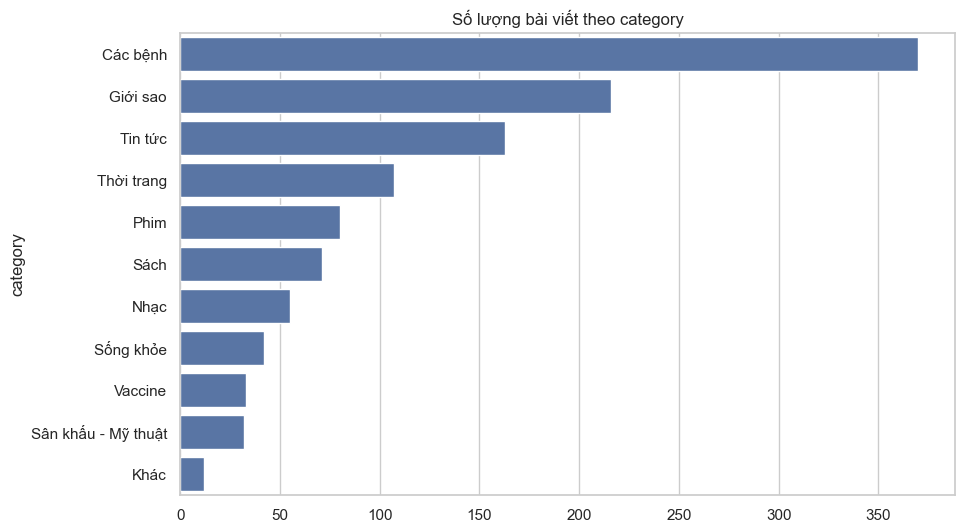

In [31]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    y=category_counts.index,
    x=category_counts.values
)

plt.title("Số lượng bài viết theo category")

plt.show()

### 3.3 Phân bố số lượng bình luận

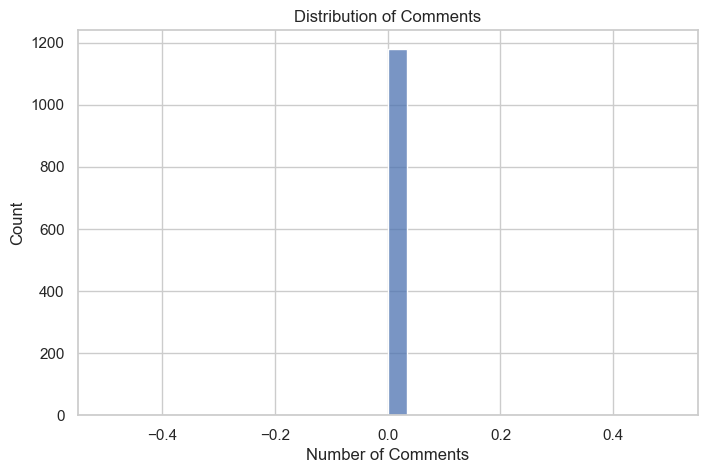

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Distribution of Comments")

plt.xlabel("Number of Comments")

plt.show()

### 3.4 Phân tích độ dài title và content

In [33]:
df["title_length"] = df["title"].fillna("").apply(lambda x: len(x.split()))
df["content_length"] = df["content"].fillna("").apply(lambda x: len(x.split()))

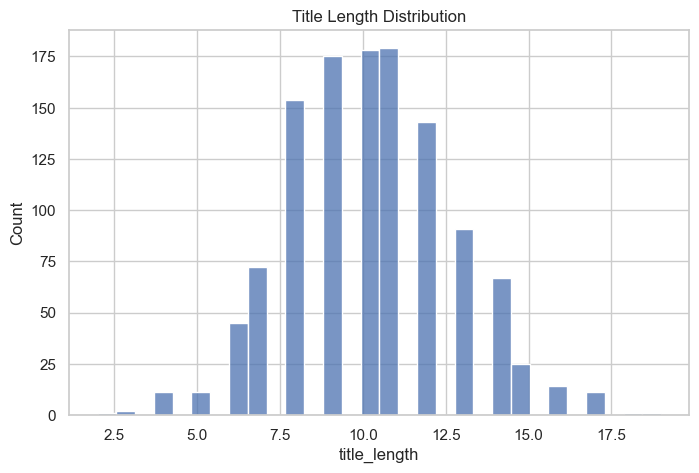

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

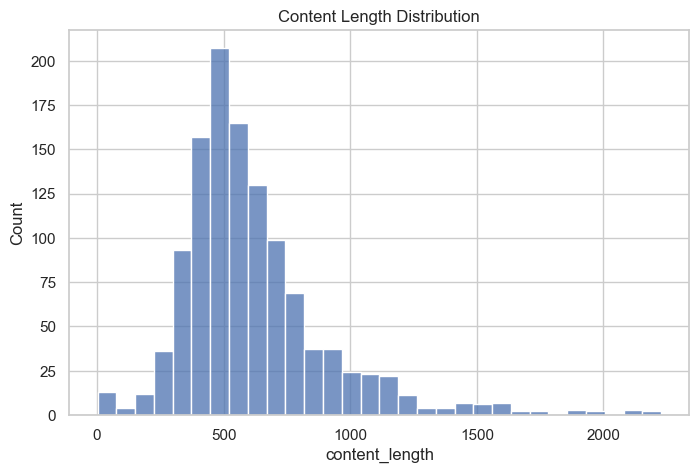

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

### 3.5 Kiểm tra bài viết bất thường

In [36]:
df.sort_values("content_length", ascending=False).head()

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url,title_length,content_length
544,'Bóng đá Việt Nam' (kỳ 1): Huấn luyện cầu thủ ...,"Giai đoạn đất nước còn chiến tranh, thế hệ cầu...","Thứ hai, 26/1/2026, 10:39 (GMT+7)",Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,https://i1-giaitri.vnecdn.net/2026/01/14/dd3f2...,(Trích sáchBóng đá Việt Nam 1896-2025: Ký ức v...,"đội thể công, bóng đá việt nam, bóng đá việt n...",Giải trí,Sách,0,https://vnexpress.net/bong-da-viet-nam-ky-1-hu...,13,2228
325,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,https://i1-giaitri.vnecdn.net/2026/01/14/1a9ef...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,Sách,0,https://vnexpress.net/bong-da-viet-nam-ky-2-tr...,13,2194
519,Đạo diễn Nguyễn Hoàng Điệp: Con trẻ sẽ đọc sác...,"Đạo diễn Nguyễn Hoàng Điệp cho rằng không ""thầ...","Thứ tư, 25/2/2026, 12:13 (GMT+7)","Bên cạnh công việc làm phim, đạo diễn Nguyễn H...",https://i1-giaitri.vnecdn.net/2026/02/13/ff4a2...,Khánh Linh,"đạo diễn nguyễn hoàng điệp, đọc sách, tủ sách ...",Giải trí,Sách,0,https://vnexpress.net/dao-dien-nguyen-hoang-di...,16,2152
882,Tự truyện Bob Iger - đằng sau thương vụ tỷ USD,"Khi đọc ''The Ride of a Lifetime'', có lúc tôi...","Thứ năm, 12/3/2026, 19:07 (GMT+7)","* Bài cảm nhận cho chuyên mục ""Cuốn sách tôi y...",https://i1-giaitri.vnecdn.net/2026/03/12/nxbtr...,Ân Nguyễn,"tự truyện của bob iger, cuốn sách tôi yêu",Giải trí,Sách,0,https://vnexpress.net/tu-truyen-bob-iger-dang-...,11,2102
788,Sách của nhà sư Thích Pháp Hòa (kỳ một): dạy c...,"Trong sách ""Lá hoa trên đường về"", nhà sư Thíc...","Thứ bảy, 21/2/2026, 10:10 (GMT+7)",SáchLá hoa trên đường vềtuyển tập những vấn đá...,https://i1-giaitri.vnecdn.net/2026/02/16/thich...,"(Trích sáchLá hoa trên đường về, công ty sáchF...",nhà sư thích pháp hòa,Giải trí,Sách,0,https://vnexpress.net/sach-cua-nha-su-thich-ph...,12,2085


## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Có thể tồn tại dữ liệu thiếu
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:

- Loại bỏ duplicates
- Chuẩn hóa text
- Chuẩn hóa date
- Xử lý missing values

## 5. Định hướng bài toán

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận
- Input: title_length, content_length, category...
- Output: nums_of_comments

### Hướng 2: Phân loại bài viết
- Phân loại bài viết thuộc nhóm:
  - Sức khỏe
  - Giải trí

### Hướng 3: Phân tích xu hướng nội dung
- Phân tích chủ đề phổ biến
- Phân tích độ dài bài viết